In [1]:
import numpy as np
import pandas
import dpluspy 
import demes
import demesdraw
import matplotlib, matplotlib.pylab as plt

matplotlib.rc("xtick", labelsize=8)
matplotlib.rc("ytick", labelsize=8)
matplotlib.rc("axes", labelsize=8)
matplotlib.rc("axes", titlesize=8)
matplotlib.rc("legend", fontsize=8)

In [2]:

u = 1.3e-8

best_fit = "fitted_models/full_model_round_1_fit_10.yaml"
data_file = "../../../analyses/recombination_maps/stats/subset_Bherer.pkl"

data = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=best_fit, return_dict=True)

model = dpluspy.inference.compute_bin_stats(
    best_fit, sampled_demes=data["pop_ids"], bins=data["bins"], u=u)

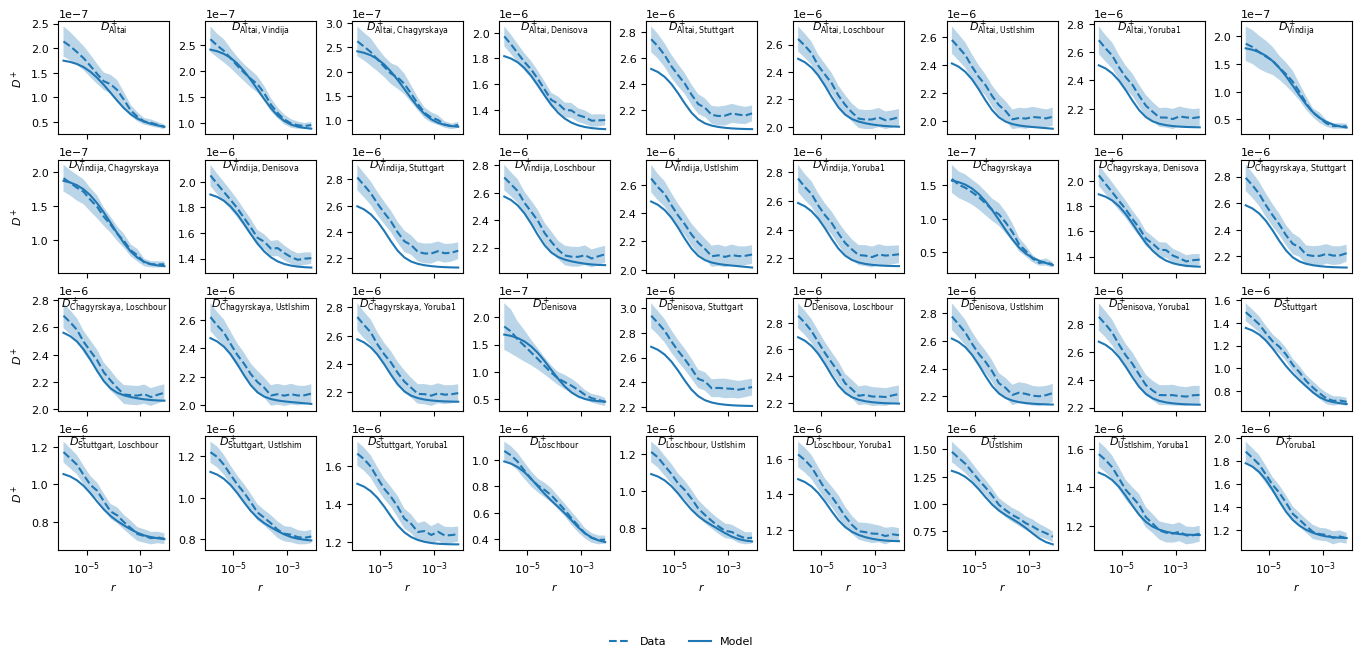

In [4]:
dpluspy.plotting.plot_D_plus_curves(
    models=model,
    pop_ids=data["pop_ids"], 
    bins=data["bins"], 
    means=data["means"], 
    varcovs=data["varcovs"], 
    ax_size=1.5, cols=9,
    out="figures/full_model_round_1_fit_10.pdf",    
)


In [5]:
# Make a table of fitted parameters

dfs = []
param_file = "full_model_round_1_params.yaml"

for rep in range(30):
    graph_file = f"fitted_models/full_model_round_1_fit_{rep}.yaml"
    pnames, params = dpluspy.inference._load_params(graph_file, param_file)
    pdict = {"rep": rep}
    pdict.update({pname: [p] for pname, p in zip(pnames, params)})
    dfs.append(pandas.DataFrame(pdict))

param_df = pandas.concat(dfs)
param_df.to_csv("fitted_parameters.csv", index=False)
print(param_df.to_string(index=False))

 rep        T_NDMH          T_ND        T_MH_N         T_AWN         T_CV         T_OOA        T_Bas        T_L_S        N_Anc        N_ND       N_Den         N_N     N_Chag       N_Vin      N_Alt         N_MH        N_Yor       N_OOA       N_Los       N_Stu       N_Ust   p_S_ND    p_S_D    p_H_N   p_H_NW  p_N_OOA    p_L_S     m_ND         m_SL         m_SY     m_LY
   0 759186.097807 721782.000325 397201.839003 116760.934897 57326.613003  66181.682326 58759.871932  7000.771466 15135.539480 1799.784159 3107.369618 3022.068093  86.368793  624.901374  72.889568 34357.328444 13604.373097  484.157638 1298.404923 5385.691883 9941.241946 0.036433 0.011810 0.104793 0.009808 0.028145 0.296989 0.000006 5.390440e-06 1.422869e-06 0.000114
   1 824945.205863 778861.867249 399999.988218 116835.604309 61145.096232  67412.465404 60847.295832  7000.001103 13949.580704 3034.147800 2854.235420 2798.371536 251.804545  873.504707  75.447159 38986.496976 13173.248972  423.801037 1349.342917 4680.696405 941

In [8]:
# How different is the ll when we use the midpoint approximation?

model_midpoint = dpluspy.inference.compute_bin_stats(
    best_fit, sampled_demes=data["pop_ids"], bins=data["bins"], u=u,
    approx="midpoint")

ll = dpluspy.inference.composite_ll(model, data["means"], data["varcovs"])
ll_midpoint = dpluspy.inference.composite_ll(
    model_midpoint, data["means"], data["varcovs"])

print(f"ll = {ll}")
print(f"ll_midpoint = {ll_midpoint}")

ll = -1347.257782713932
ll_midpoint = -1348.6032026190537


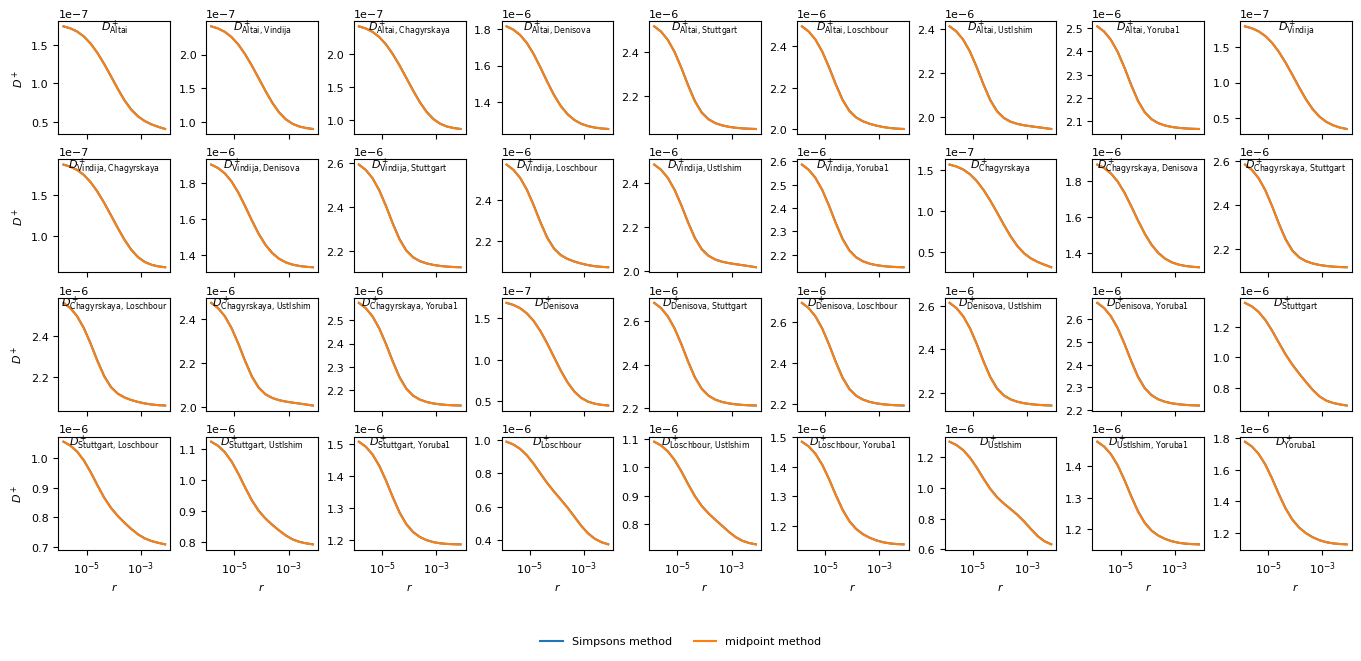

In [10]:
dpluspy.plotting.plot_D_plus_curves(
    models=[model, model_midpoint],
    pop_ids=data["pop_ids"], 
    bins=data["bins"], 
    ax_size=1.5, cols=9,
    out="figures/approximation_methods.pdf",
    labels=["Simpsons method", "midpoint method"]
)
